# District-level Δr — does the crop mask help *within* each district?

`gsv_preds_exploration.ipynb` computes **one pooled correlation per state**: all districts
and all years thrown into a single Pearson r. This notebook computes a **separate
correlation for each district** across its 12 years, then measures how masking changes it.

The two answer different questions:

| Statistic | Question it answers |
|---|---|
| **Pooled** (state) | Does masked GCVI rank *districts* by yield better? |
| **Per-district** (here) | Does masked GCVI track a district's *year-to-year* yield changes better? |

For forecasting, the second is usually the more relevant one — but the two can disagree,
and in this data they do. That divergence is documented in the final section.

Output: `../../outputs/district_level_delta.csv`

In [1]:
import nbformat, numpy as np, pandas as pd, os, glob, re
from scipy import stats
import matplotlib.pyplot as plt

os.makedirs('../../outputs', exist_ok=True)

# Reuse the config + helpers from the state-level notebook so the GCVI extraction,
# NAME_FIXES and mask conventions are guaranteed identical.
SRC = '../02_mask_analysis/gsv_preds_exploration.ipynb'
_nb  = nbformat.read(SRC, as_version=4)
_cfg = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
ns = {}
exec(_cfg, ns)
REGIONS, REGION_MASKS = ns['REGIONS'], ns['REGION_MASKS']
load_yield, extract_gcvi = ns['load_yield'], ns['extract_gcvi']
REGION_LABELS = ns['REGION_LABELS']
print(f"reusing config from {SRC}: {len(REGIONS)} states")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
reusing config from ../02_mask_analysis/gsv_preds_exploration.ipynb: 30 states


## 1. Per-district correlations

For each state we extract district-mean GCVI twice — once unmasked (`raw`) and once with
the crop mask — join both to district yield, and compute a Pearson r **per district**
across years.

Guards applied to each district:
- at least **5 usable years** (a 12-point series is already thin; below 5 is meaningless)
- non-zero variance in both GCVI and yield, else `pearsonr` returns NaN silently

⚠ Each district correlation rests on ~12 observations, so individual values are noisy.
Only aggregate patterns should be read from them.

In [2]:
MIN_YEARS = 5
rows, skipped = [], []

for rk, cfg in REGIONS.items():
    try:
        yl = load_yield(cfg['state_name'])
        crop_mask = REGION_MASKS[rk][2]          # 'crop' for Punjab/MP, else 'jordi'

        panels = {}
        for m in ['raw', crop_mask]:
            g = extract_gcvi(rk, m).merge(yl, on=['district', 'year'], how='inner').dropna()
            g.loc[g['gcvi_mean'] == 0, 'yield_kg_ha'] = 0
            panels[m] = g

        raw_df, msk_df = panels['raw'], panels[crop_mask]
        for d in sorted(set(raw_df['district']) & set(msk_df['district'])):
            a = raw_df[raw_df['district'] == d]
            b = msk_df[msk_df['district'] == d]
            if len(a) < MIN_YEARS or len(b) < MIN_YEARS:
                skipped.append((rk, d, 'too few years')); continue
            if (a['gcvi_mean'].nunique() < 2 or a['yield_kg_ha'].nunique() < 2 or
                b['gcvi_mean'].nunique() < 2 or b['yield_kg_ha'].nunique() < 2):
                skipped.append((rk, d, 'zero variance')); continue

            r_raw = stats.pearsonr(a['gcvi_mean'], a['yield_kg_ha'])[0]
            r_msk = stats.pearsonr(b['gcvi_mean'], b['yield_kg_ha'])[0]
            if not (np.isfinite(r_raw) and np.isfinite(r_msk)):
                skipped.append((rk, d, 'non-finite r')); continue

            rows.append({'region_key': rk, 'State': cfg['state_name'],
                         'region_label': REGION_LABELS[rk], 'district': d,
                         'n_years': len(a), 'r_raw': r_raw, 'r_mask': r_msk,
                         'delta': r_msk - r_raw,
                         'rel': (r_msk - r_raw) / (1 - r_raw)})
        print(f"  {rk:<20} ok", flush=True)
    except Exception as e:
        print(f"  {rk:<20} FAILED  {type(e).__name__}: {e}", flush=True)

dd = pd.DataFrame(rows)
dd.to_csv('../../outputs/district_level_delta.csv', index=False)
print(f"\n{len(dd)} districts across {dd['region_key'].nunique()} states"
      f"   ({len(skipped)} skipped)")
if skipped:
    from collections import Counter
    for reason, n in Counter(r for _, _, r in skipped).items():
        print(f"   skipped — {reason}: {n}")

  punjab               ok


  mp                   ok


  up                   ok


  wb                   ok


  telangana            ok


...

  andaman_nicobar      ok


<string>:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


  dadra_nagar_haveli   ok



514 districts across 27 states   (110 skipped)
   skipped — zero variance: 83
   skipped — too few years: 27


<string>:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


## 2. How much does the mask help at district level?

districts            : 514
median years/district: 12
mean   Δr            : +0.0079
median Δr            : +0.0079
improved (Δr > 0)    : 57%
one-sample t-test vs 0: t=0.95, p=0.3441


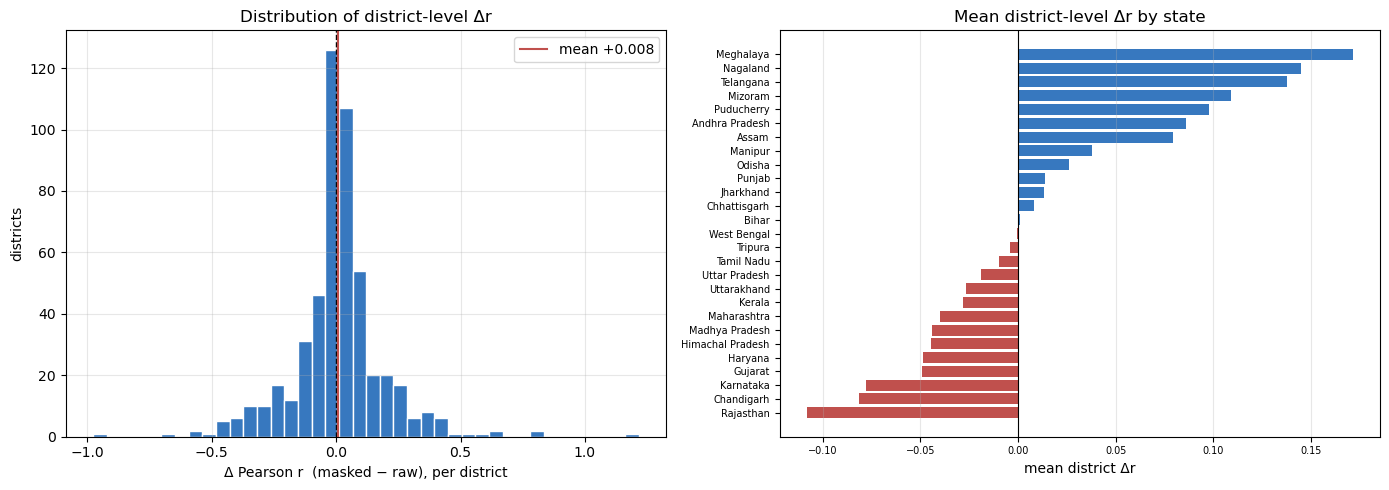

In [3]:
print(f"districts            : {len(dd)}")
print(f"median years/district: {dd['n_years'].median():.0f}")
print(f"mean   Δr            : {dd['delta'].mean():+.4f}")
print(f"median Δr            : {dd['delta'].median():+.4f}")
print(f"improved (Δr > 0)    : {100 * (dd['delta'] > 0).mean():.0f}%")
t, p = stats.ttest_1samp(dd['delta'].dropna(), 0)
print(f"one-sample t-test vs 0: t={t:.2f}, p={p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dd['delta'].dropna(), bins=40, color='#3778bf', edgecolor='white')
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].axvline(dd['delta'].mean(), color='#c0504d', lw=1.5,
                label=f"mean {dd['delta'].mean():+.3f}")
axes[0].set_xlabel('Δ Pearson r  (masked − raw), per district')
axes[0].set_ylabel('districts'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Distribution of district-level Δr')

o = dd.groupby('region_label')['delta'].mean().sort_values()
axes[1].barh(o.index, o.values, color=np.where(o.values > 0, '#3778bf', '#c0504d'))
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('mean district Δr'); axes[1].tick_params(labelsize=7)
axes[1].set_title('Mean district-level Δr by state'); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../../outputs/district_delta_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pooled vs per-district — they disagree

The state-level notebook reports a large mean improvement (Δr ≈ +0.44 pooled). Averaging
the per-district Δr gives something far smaller. Both are correct; they measure different
things.

pooled Δr   : mean +0.438
district Δr : mean +0.013

r(pooled Δr, mean district Δr) = -0.01  p=0.9735  n=27


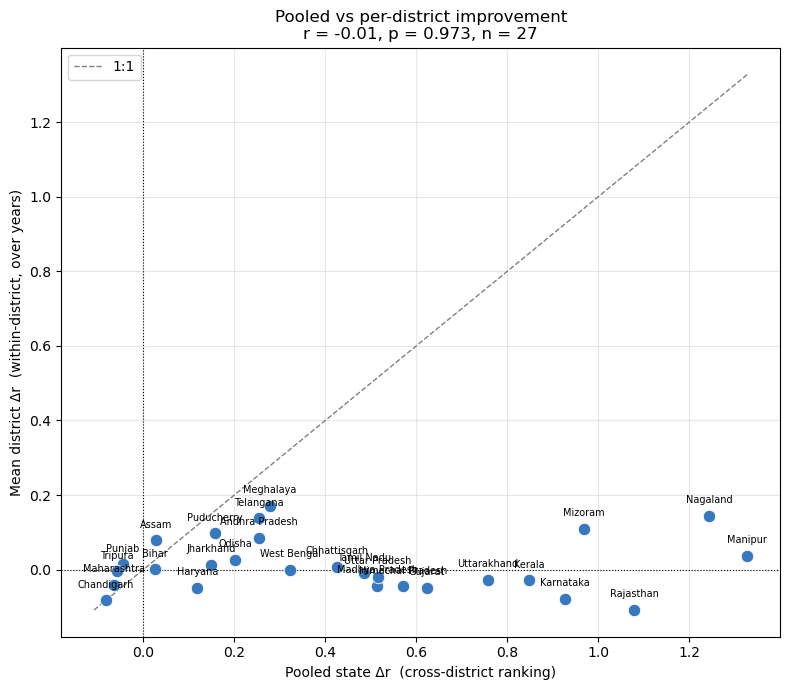

In [4]:
pooled = pd.read_csv('../../outputs/gcvi_yield_correlation.csv')
pr = []
for k in pooled['region'].unique():
    s = pooled[pooled['region'] == k]
    raw  = s[s['mask'] == 'raw']['r'].values
    crop = s[s['mask'].isin(['crop', 'jordi'])]['r'].values
    b = next(iter(raw), np.nan)
    pr.append({'region_key': k, 'pooled_baseline': b,
               'pooled_delta': next(iter(crop - raw), np.nan)})
P = pd.DataFrame(pr)

D = (dd.groupby(['region_key', 'region_label'])
       .agg(district_delta=('delta', 'mean'), n_dist=('delta', 'size'))
       .reset_index().merge(P, on='region_key', how='inner').dropna())

r, p = stats.pearsonr(D['pooled_delta'], D['district_delta'])
print(f"pooled Δr   : mean {D['pooled_delta'].mean():+.3f}")
print(f"district Δr : mean {D['district_delta'].mean():+.3f}")
print(f"\nr(pooled Δr, mean district Δr) = {r:+.2f}  p={p:.4f}  n={len(D)}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(D['pooled_delta'], D['district_delta'], s=80, color='#3778bf',
           edgecolors='white', linewidths=0.6, zorder=3)
for _, row in D.iterrows():
    ax.annotate(row['region_label'], (row['pooled_delta'], row['district_delta']),
                fontsize=7, textcoords='offset points', xytext=(0, 9), ha='center')
lo = min(D['pooled_delta'].min(), D['district_delta'].min())
hi = max(D['pooled_delta'].max(), D['district_delta'].max())
ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1, label='1:1')
ax.axhline(0, color='black', lw=0.8, ls=':'); ax.axvline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Pooled state Δr  (cross-district ranking)')
ax.set_ylabel('Mean district Δr  (within-district, over years)')
ax.set_title(f'Pooled vs per-district improvement\nr = {r:+.2f}, p = {p:.3f}, n = {len(D)}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../outputs/pooled_vs_district_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

**1. At district level the crop mask barely helps.** Mean Δr is near zero and only about
half of districts improve — against a pooled state-level mean of roughly +0.44. The mask's
apparent benefit comes almost entirely from **ranking districts against each other**, not
from tracking any single district's year-to-year variation.

**2. Each district correlation rests on ~12 points.** Individual district values are very
noisy; only the aggregate distribution is meaningful.

**3. The two statistics can disagree in sign for the same predictor.** Census rice share
correlates **negatively** with pooled state Δr but **positively** with mean district Δr.
That is a Simpson's-paradox-shaped result, not an error — decide which question you are
answering before quoting either number.

**Practical implication:** if the goal is a *forecasting* model that predicts a district's
yield in an unseen year, the district-level result is the relevant one, and it says the
crop mask contributes little. If the goal is a cross-sectional map of relative yield, the
pooled result applies.